# **Import Libraries**

In [1]:
!pip install idx2numpy

  Preparing metadata (setup.py) ... done
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=7903 sha256=0662045717ec637448ff7fbb27c5dd278523e0831883ca37d17765796c0a708f
  Stored in directory: /root/.cache/pip/wheels/f7/48/00/ae031c97d62f39e1c3c4daa00426c09a65eb29ae5753a189ee
Successfully built idx2numpy


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import idx2numpy

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import(
    confusion_matrix,
    classification_report
)

# **Setting Seed For Reusibility**

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

# **Load Dataset**

In [4]:
X_train = idx2numpy.convert_from_file("/content/sample_data/train-images-idx3-ubyte")
y_train = idx2numpy.convert_from_file("/content/sample_data/train-labels-idx1-ubyte")

X_test = idx2numpy.convert_from_file("/content/sample_data/t10k-images-idx3-ubyte")
y_test = idx2numpy.convert_from_file("/content/sample_data/t10k-labels-idx1-ubyte")

# **Explore the Dataset**

In [5]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


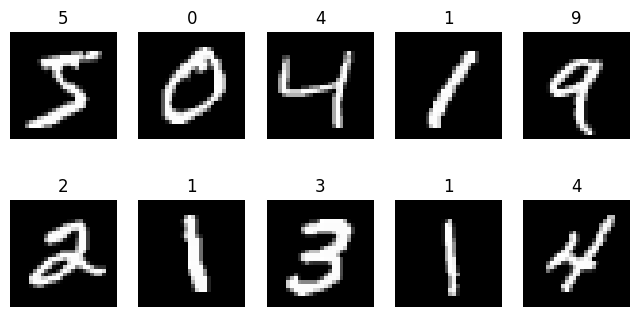

In [6]:
plt.figure(figsize=(8,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

# **Normalize the images**

In [7]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# **Flatten the images**

In [8]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

# **Build the neural network**

In [9]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(10)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Compile the model**

In [10]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# **Train the model**

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9264 - loss: 0.2501 - val_accuracy: 0.9667 - val_loss: 0.1119
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9685 - loss: 0.1042 - val_accuracy: 0.9687 - val_loss: 0.1022
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9783 - loss: 0.0708 - val_accuracy: 0.9712 - val_loss: 0.0930
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9847 - loss: 0.0517 - val_accuracy: 0.9733 - val_loss: 0.0908
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9880 - loss: 0.0388 - val_accuracy: 0.9703 - val_loss: 0.1076
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9904 - loss: 0.0309 - val_accuracy: 0.9725 - val_loss: 0.1078
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9909 - loss: 0.0281 - val_accuracy: 0.9738 - val_loss: 0.1223
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9926 - loss: 0.0217 -

# **Evaluate the model**

In [12]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9717 - loss: 0.1266
Test Accuracy: 0.9717000126838684


# **Make predictions**

In [13]:
logits = model.predict(X_test)

probabilities = tf.nn.softmax(logits)

predictions = tf.argmax(probabilities, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


# **Showing predictions**

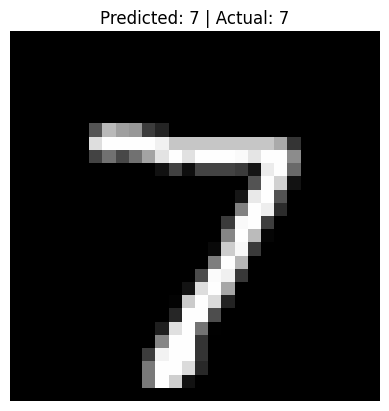

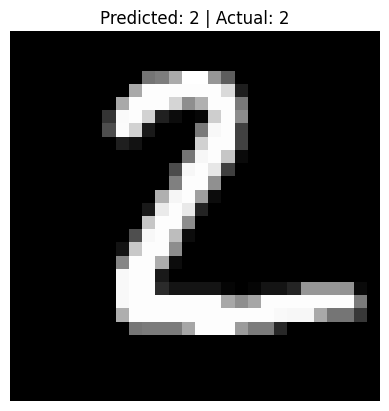

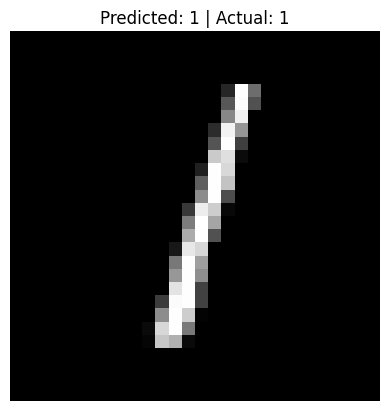

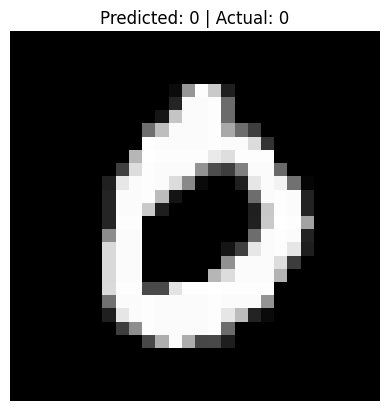

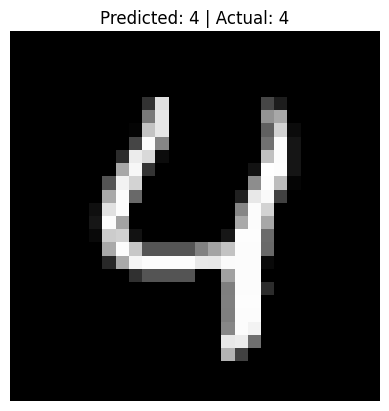

In [14]:
for i in range (5):
  index = i

  plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
  plt.title(f"Predicted: {predictions[index].numpy()} | Actual: {y_test[index]}")
  plt.axis("off")
  plt.show()

# **Confusion Matrix**

In [15]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[ 967    0    3    2    0    0    7    0    1    0]
 [   0 1118    0    2    0    2    4    0    9    0]
 [   5    3  978   19    6    0    6    3   11    1]
 [   0    1    1  989    0   11    0    1    7    0]
 [   0    0    2    0  960    0    6    1    1   12]
 [   1    1    0    9    0  867    5    0    7    2]
 [   4    2    0    1    5    4  940    0    2    0]
 [   1    3   11   10    2    1    1  979   10   10]
 [   1    0    1    7    1    3    0    1  958    2]
 [   2    2    1   11    8   12    0    2   10  961]]


# **Classification Report**

In [16]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.95      0.96      1032
           3       0.94      0.98      0.96      1010
           4       0.98      0.98      0.98       982
           5       0.96      0.97      0.97       892
           6       0.97      0.98      0.98       958
           7       0.99      0.95      0.97      1028
           8       0.94      0.98      0.96       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

